In [23]:
# 🏠 House Price Prediction using Machine Learning

# 📗 Part B: Dataset Understanding & Preparation

In [6]:
# 📚 Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [4]:
# 📂 Load Dataset
df = pd.read_csv("Dataset/RealEstate_HousePrice_Dataset_4200.csv")

df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_garage.1,has_pool,renovation_years_ago,house_price_inr
0,100001.0,1973.0,5.0,4.0,7.6,23.0,11.9,5220.0,1.0,1.0,0.0,0.0,40275084.0
1,100002.0,1560.0,3.0,3.0,6.3,13.0,15.8,3882.0,1.0,1.0,0.0,13.0,26812029.0
2,100003.0,2071.0,4.0,3.0,5.8,9.0,21.1,4488.0,0.0,0.0,0.0,9.0,29315677.0
3,100004.0,2640.0,5.0,3.0,7.7,12.0,7.9,3614.0,1.0,1.0,1.0,4.0,47712959.0
4,100005.0,1498.0,3.0,3.0,3.8,15.0,24.0,2663.0,0.0,0.0,0.0,15.0,17724566.0


In [ ]:
# 📌 Task 7: Identify Independent and Dependent Variables

In this step, we identify the input features (independent variables) and the target variable (dependent variable) for the machine learning model.

In [11]:
# Independent Variables
X = df.drop("house_price_inr", axis=1)

# Dependent Variable
y = df["house_price_inr"]

print("Independent Variables (X):")
print(X.columns)

print("\nDependent Variable (Y):")
print(y.name)

Independent Variables (X):
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_garage.1', 'has_pool', 'renovation_years_ago'],
      dtype='object')

Dependent Variable (Y):
house_price_inr


In [21]:
### Observation

# - **Independent Variables (X):**
#   - House Area (sq.ft.)
#   - Number of Bedrooms
#   - Number of Bathrooms
#   - Location Score
#   - Age of Property
#   - Distance from City
#   - Lot Size
#   - Garage
#   - Pool
#   - Renovation Years Ago
#   - (Other predictor columns)

# - **Dependent Variable (Y):**
#   - House Price (`house_price_inr`)

# The independent variables are used to predict the target variable (house price).

In [12]:
 # 📌 Task 8: Visualize Relationships Between Features and Target Variable

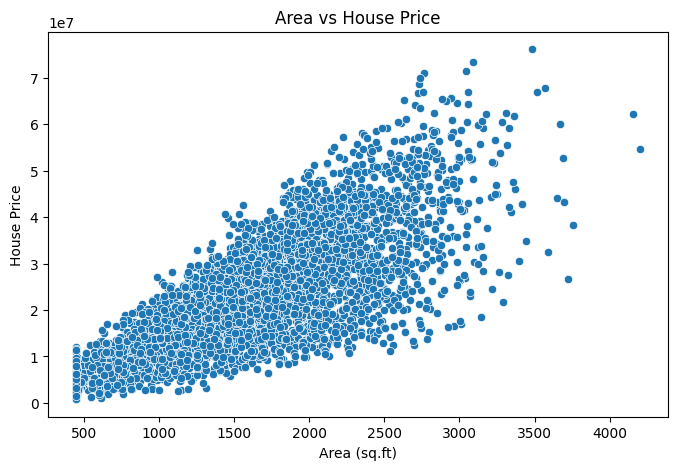

In [13]:
# Graph 1 – Area vs House Price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="area_sqft", y="house_price_inr")

plt.title("Area vs House Price")
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price")
plt.show()

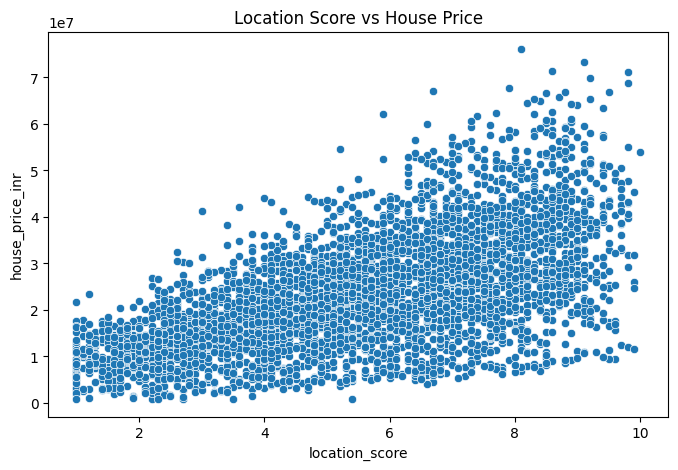

In [14]:
# Graph 2 – Location Score vs House Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="location_score", y="house_price_inr")

plt.title("Location Score vs House Price")
plt.show()

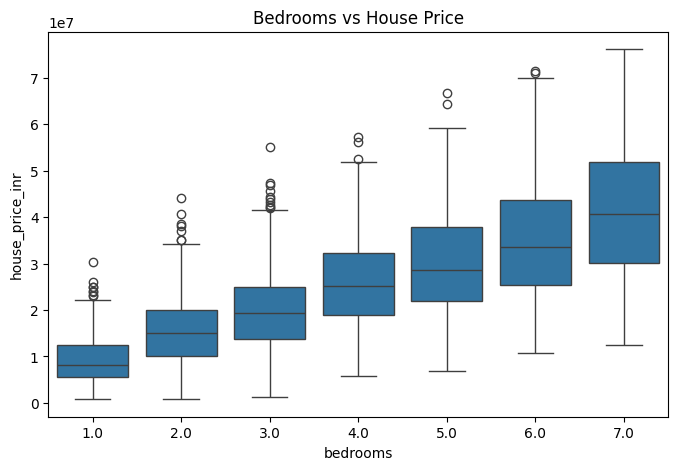

In [15]:
# Graph 3 – Bedrooms vs House Price
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="bedrooms", y="house_price_inr")

plt.title("Bedrooms vs House Price")
plt.show()

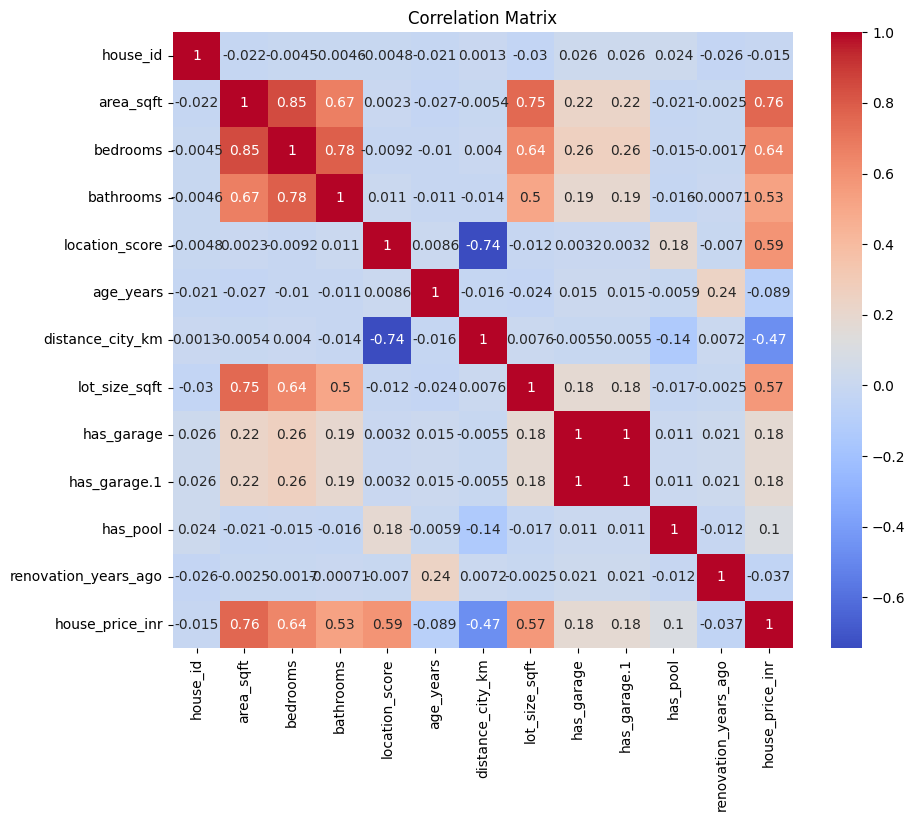

In [16]:
# Graph 4 – Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [18]:
# 📌 Task 9: Split the Dataset into Training and Testing Sets

# The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (3361, 12)
Testing Features  : (841, 12)
Training Target   : (3361,)
Testing Target    : (841,)


In [47]:
                                                           # 📘 Part C: Simple Linear Regression

In [43]:
# ⚙️Task 10: Implement Simple Linear Regression
from sklearn.linear_model import LinearRegression

# Drop rows with NaN in area_sqft or house_price_inr
df_clean = df[['area_sqft','house_price_inr']].dropna()

# Define X and y
X = df_clean[['area_sqft']]
y = df_clean['house_price_inr']

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X, y)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[14852.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area_sqft']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.122e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


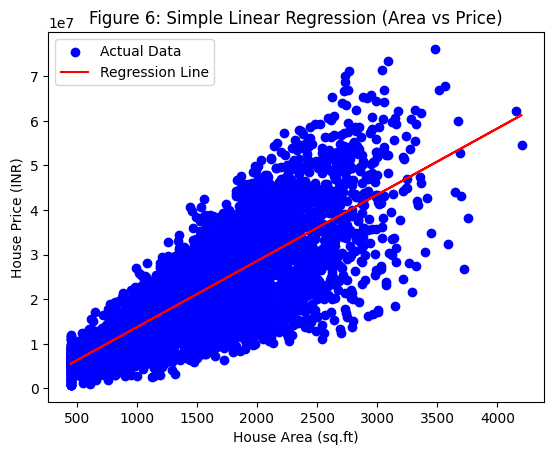

Intercept (β0): -1122176.2691293508
Slope (β1): 14852.282401870778


In [44]:
# 🌟 Task 11: Plot Regression Line & Interpret Slope/Intercept

import matplotlib.pyplot as plt

# Scatter plot of actual data
plt.scatter(X, y, color='blue', label='Actual Data')

# Regression line
plt.plot(X, lin_reg.predict(X), color='red', label='Regression Line')

# Labels and title
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.title("Figure 6: Simple Linear Regression (Area vs Price)")
plt.legend()
plt.show()

# Print slope and intercept
print("Intercept (β0):", lin_reg.intercept_)
print("Slope (β1):", lin_reg.coef_[0])


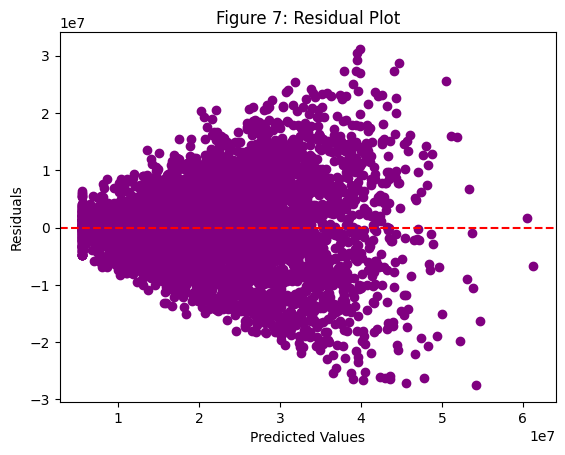

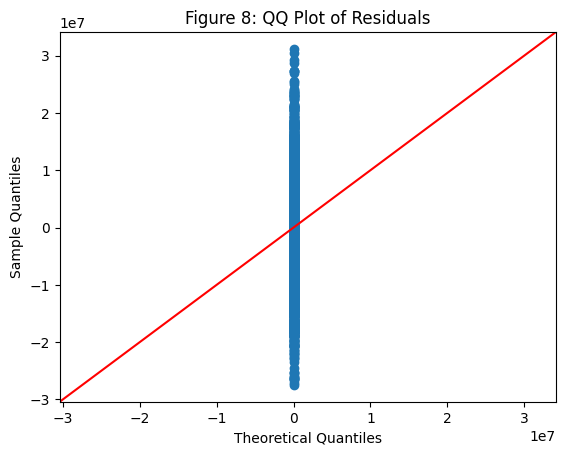

In [46]:
# 🌟 Task 12: Validate Linear Regression Assumptions
import statsmodels.api as sm

# Predicted values
y_pred = lin_reg.predict(X)

# Residuals
residuals = y - y_pred

# Residual Plot
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Figure 7: Residual Plot")
plt.show()

# QQ Plot for Normality of Residuals
sm.qqplot(residuals, line='45')
plt.title("Figure 8: QQ Plot of Residuals")
plt.show()


In [48]:
                                            # 📊 Part D: Model Evaluation Metrics

In [49]:
# 🌟 Task 13: Evaluate Simple Linear Regression Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions
y_pred = lin_reg.predict(X)

# Metrics
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

# Adjusted R²
n = X.shape[0]   # number of observations
p = X.shape[1]   # number of predictors (here = 1)
adj_r2 = 1 - (1-r2) * (n-1)/(n-p-1)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Adjusted R² Score:", adj_r2)


Mean Squared Error (MSE): 65919720964917.47
Mean Absolute Error (MAE): 6290026.1825628
Root Mean Squared Error (RMSE): 8119096.068215813
R² Score: 0.5706802782327891
Adjusted R² Score: 0.5705780105525207


In [50]:
                                         # ⚙️ Part E: Multiple Linear Regression

In [53]:
# 🌟 Task 15: Implement Multiple Linear Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predictions from Multiple LR
y_pred_multi = mlr.predict(X_multi)

# Metrics
mse_multi = mean_squared_error(y_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_multi, y_pred_multi)

# Adjusted R²
n = X_multi.shape[0]   # number of observations
p = X_multi.shape[1]   # number of predictors
adj_r2_multi = 1 - (1-r2_multi) * (n-1)/(n-p-1)

print("MSE:", mse_multi)
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)
print("Adjusted R²:", adj_r2_multi)


MSE: 12102283776204.56
MAE: 2617189.7012030934
RMSE: 3478833.6804458704
R²: 0.9211806569036729
Adjusted R²: 0.9210678698637068


In [54]:
# 🌟 Task 16: Compare Simple vs Multiple Linear Regression

# Collect metrics from Simple LR (Task 13)
metrics_simple = {
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2,
    "Adjusted R²": adj_r2
}

# Collect metrics from Multiple LR (Task 15)
metrics_multi = {
    "MSE": mse_multi,
    "MAE": mae_multi,
    "RMSE": rmse_multi,
    "R²": r2_multi,
    "Adjusted R²": adj_r2_multi
}

# Create comparison table
comparison_df = pd.DataFrame([metrics_simple, metrics_multi],
                             index=["Simple LR", "Multiple LR"])
comparison_df


,MSE,MAE,RMSE,R²,Adjusted R²
Simple LR,6.591972e+13,6.290026e+06,8.119096e+06,0.570680,0.570578
Multiple LR,1.210228e+13,2.617190e+06,3.478834e+06,0.921181,0.921068


In [56]:
                                               # ⚙️ Part F: Polynomial Regression

In [57]:
# 🌟 Task 18: Polynomial Regression (degree 2)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use area_sqft as predictor for polynomial regression
X_poly = df[['area_sqft']].dropna()
y_poly = df['house_price_inr'].dropna()

# Transform features into polynomial terms (degree 2 or 3)
poly = PolynomialFeatures(degree=2)
X_poly_transformed = poly.fit_transform(X_poly)

# Train polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(X_poly_transformed, y_poly)

# Predictions
y_pred_poly = poly_reg.predict(X_poly_transformed)

# Metrics
mse_poly = mean_squared_error(y_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_poly, y_pred_poly)

print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)


MSE: 65895304440381.59
RMSE: 8117592.280989579
R²: 0.570839297345231


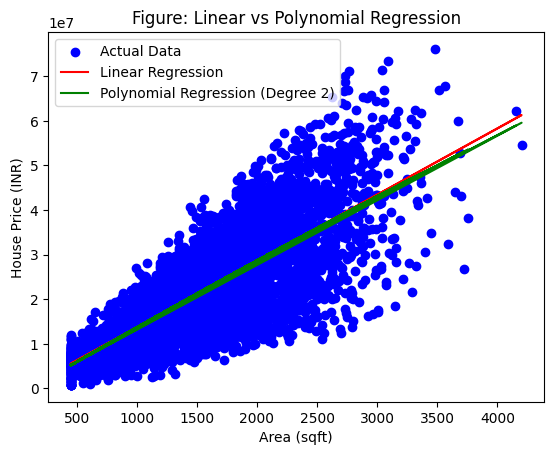

In [58]:
# Task 19: 📊 Compare Linear vs Polynomial Regression
import matplotlib.pyplot as plt

plt.scatter(X_poly, y_poly, color='blue', label="Actual Data")

# Linear Regression line
plt.plot(X, lin_reg.predict(X), color='red', label="Linear Regression")

# Polynomial Regression curve
plt.plot(X_poly, y_pred_poly, color='green', label="Polynomial Regression (Degree 2)")

plt.xlabel("Area (sqft)")
plt.ylabel("House Price (INR)")
plt.title("Figure: Linear vs Polynomial Regression")
plt.legend()
plt.show()

In [59]:
                                              # 📝 Part G: Gradient Descent Optimization

In [60]:
# Task 22: ⚙️ Batch Gradient Descent (from scratch)
import numpy as np

# Example: Simple Linear Regression with Gradient Descent
X = df[['area_sqft']].values
y = df['house_price_inr'].values

# Normalize features
X = (X - X.mean()) / X.std()

# Add bias term
X_b = np.c_[np.ones((len(X),1)), X]

# Initialize parameters
theta = np.random.randn(2,1)
learning_rate = 0.01
iterations = 1000

# Batch Gradient Descent
for i in range(iterations):
    gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(theta) - y.reshape(-1,1))
    theta = theta - learning_rate * gradients

print("Final parameters (Batch GD):", theta)


Final parameters (Batch GD): [[nan]
 [nan]]


In [61]:
# Task 23: ⚙️ Stochastic Gradient Descent (SGD)
theta_sgd = np.random.randn(2,1)
learning_rate = 0.01
epochs = 50

for epoch in range(epochs):
    for i in range(len(X_b)):
        random_index = np.random.randint(len(X_b))
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta_sgd) - yi.reshape(-1,1))
        theta_sgd = theta_sgd - learning_rate * gradients

print("Final parameters (SGD):", theta_sgd)


Final parameters (SGD): [[nan]
 [nan]]


In [62]:
# Task 24: ⚙️ Mini‑Batch Gradient Descent
theta_mbgd = np.random.randn(2,1)
learning_rate = 0.01
epochs = 50
batch_size = 32

for epoch in range(epochs):
    shuffled_indices = np.random.permutation(len(X_b))
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, len(X_b), batch_size):
        xi = X_b_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = 2/len(xi) * xi.T.dot(xi.dot(theta_mbgd) - yi.reshape(-1,1))
        theta_mbgd = theta_mbgd - learning_rate * gradients

print("Final parameters (Mini‑Batch GD):", theta_mbgd)


Final parameters (Mini‑Batch GD): [[nan]
 [nan]]
